In [1]:
import pypsa
import openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import matplotlib.patches as mpatches
#from pypsa.plot import projected_area_factordatet
from matplotlib.patches import Circle, Ellipse, Patch
from matplotlib.legend_handler import HandlerPatch
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy
import geopandas as gpd
import logging
logger = logging.getLogger()
logger.setLevel(logging.CRITICAL)

plt.rc('font',family='Ubuntu')
plt.rc('axes',edgecolor='gainsboro')
plt.rcParams['hatch.linewidth'] = 0.2

## Case 1: Simplified network with fixed prices 


### Every generator has an exogenously set marginal price, and the price for CO2 is negative
### Methanol has a fixed demand for each timestep.
### (I used nimabahrami.github.io/pypsa-drawer for the nice visual) :

### ------------------
### Result : If the price of CO2 is lower (-30 compared to -10), methanol will be cheaper


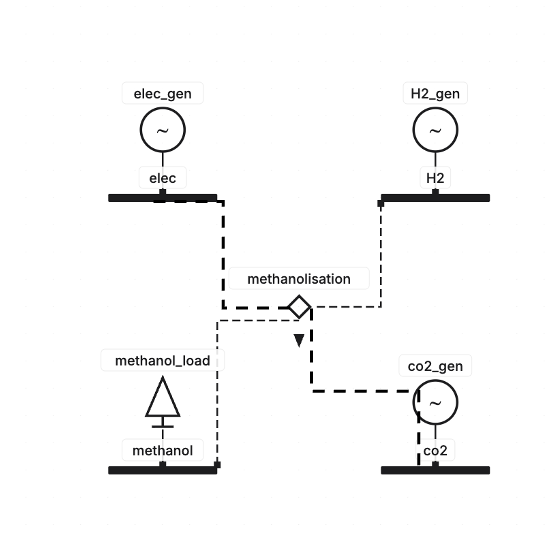

In [46]:
from IPython.display import Image
Image("Pic1.png")


In [2]:
import pypsa
import numpy as np

# Create network
n = pypsa.Network()
n.set_snapshots(range(7))  # Adjust as needed

# --- Buses ---
n.add(
    "Bus",
    "elec",
    carrier="AC",
)

n.add(
    "Generator",
    "elec_gen",
    bus="elec",
    carrier="AC",
    p_nom=10,
    marginal_cost=1,
)

n.add(
    "Bus",
    "H2",
    carrier="H2",
)

n.add(
    "Generator",
    "H2_gen",
    bus="H2",
    p_nom=10,
    marginal_cost=1,
)


n.add(
    "Bus",
    "methanol",
    carrier="methanol",
)

n.add(
    "Load",
    "methanol_load",
    bus="methanol",
    p_set=1,
)

n.add(
    "Bus",
    "co2",
    carrier="CO2",
)


n.add(
    "Generator",
    "co2_gen",
    bus="co2",
    carrier="CO2",
    p_nom=10,
    marginal_cost=[-10,-10,-30,-30,-30,-10,-10], #[-1,-1,-3,-3,-3,-1,-1],
)


# --- Links ---
n.add(
        "Link",
        "methanolisation",
        bus0='H2',
        bus1='methanol',
        bus2='elec',
        bus3='co2',
        carrier="methanolisation",
        p_nom_extendable=True,
        p_min_pu=0,
        capital_cost=100,  # EUR/MW_H2/a
        marginal_cost=100,
        lifetime=20,
        efficiency=0.8787,
        efficiency2=-0.238085,
        efficiency3=-0.217926,
    )

# --- Solve ---
n.optimize(solver_name="gurobi")  # Uncomment to solve
n.statistics()  # View results


Index(['methanolisation'], dtype='object', name='Link')
Index(['elec_gen', 'co2_gen'], dtype='object', name='Generator')
Index(['elec', 'H2', 'methanol', 'co2'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io: Writing time: 0.03s


Set parameter TokenServer to value "sophia1.hpc.ait.dtu.dk"


INFO:gurobipy:Set parameter TokenServer to value "sophia1.hpc.ait.dtu.dk"


Read LP format model from file /tmp/linopy-problem-_cn3_bm6.lp


INFO:gurobipy:Read LP format model from file /tmp/linopy-problem-_cn3_bm6.lp


...

Solved in 0 iterations and 0.01 seconds (0.00 work units)


INFO:gurobipy:Solved in 0 iterations and 0.01 seconds (0.00 work units)


Optimal objective  8.880576021e+02


INFO:gurobipy:Optimal objective  8.880576021e+02
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 29 primals, 85 duals
Objective: 8.88e+02
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.


Optimal Capacity  Installed Capacity   Supply  \
Generator -                        10.00000                10.0  7.96631   
          AC                       10.00000                10.0  1.89666   
          CO2                      10.00000                10.0  1.73607   
Link      methanolisation           1.13804                 0.0  7.00000   
Load      -                         0.00000                 0.0  0.00000   

                           Withdrawal  Energy Balance  Transmission  \
Generator -                   0.00000         7.96631           0.0   
          AC                  0.00000         1.89666           0.0   
          CO2                 0.00000         1.73607           0.0   
Link      methanolisation    11.59904        -4.59904           0.0   
Load      -                   7.00000        -7.00000           0.0   

                           Capacity Factor  Curtailment  Capital Expenditure  \
Generator -                       0.113804     62.03369              0.00000   
          AC                      0.027095     68.10334              0.00000   
          CO2                     0.024801     68.26393              0.00000   
Link      methanolisation         1.000000      0.00000            113.80448   
Load      -                            NaN      0.00000              0.00000   

                           Operational Expenditure    Revenue  Market Value  
Generator -                                7.96631    7.96631      1.000000  
          AC                               1.89666    1.89666      1.000000  
          CO2                            -32.24124  -32.24124    -18.571388  
Link      methanolisation                796.63139  910.43587    130.062270  
Load      -                                0.00000 -888.05760           NaN

In [3]:
n.buses_t.marginal_price

Bus,elec,H2,methanol,co2
snapshot,,,,
0,1.0,1.0,226.537868,-10.0
1,1.0,1.0,112.733385,-10.0
2,1.0,1.0,107.773193,-30.0
3,1.0,1.0,107.773193,-30.0
4,1.0,1.0,107.773193,-30.0
5,1.0,1.0,112.733385,-10.0
6,1.0,1.0,112.733385,-10.0


## Case 2: network with DAC (zero marginal cost)

### Instead of fixed CO2 price, a DAC link is introdced that leads from a CO2 bus to a CO2 stored bus. To force the link to be used, a negative fixed load is added to the CO2 bus (CO2 has to be captured). However, DAC only has a capital cost and does not use electricity for now.
### The CO2 sequestered bus is also added but no costs included for the link/store for now.
### H2 and elec. still have fixed exogenous prices

### ------------------
### Result : Since DAC has zero marginal cost, CO2 price is also zero.
### question: why is the capital cost for DAC recovered in only the first time-step? Is it because it's a forced installation?


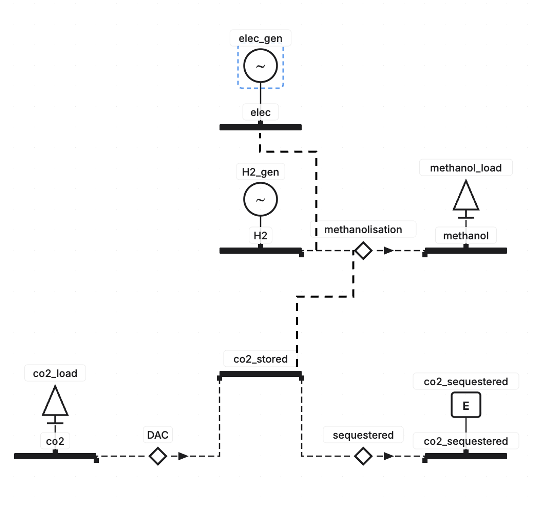

In [8]:
Image("Pic2.png")


In [7]:
import pypsa
import numpy as np

# Create network
n = pypsa.Network()
n.set_snapshots(range(7))  # Adjust as needed

# --- Buses ---
n.add(
    "Bus",
    "elec",
    carrier="AC",
)

n.add(
    "Generator",
    "elec_gen",
    bus="elec",
    carrier="AC",
    p_nom=10,
    marginal_cost=1,
)

n.add(
    "Bus",
    "H2",
    carrier="H2",
)

n.add(
    "Generator",
    "H2_gen",
    bus="H2",
    p_nom=10,
    marginal_cost=1,
)


n.add(
    "Bus",
    "methanol",
    carrier="methanol",
)

n.add(
    "Load",
    "methanol_load",
    bus="methanol",
    p_set=1,
)

n.add(
    "Bus",
    "co2",
    carrier="CO2",
)


n.add(
    "Load",
    "co2_load",
    bus="co2",
    carrier="CO2",
    p_set=-10,
    #marginal_cost=[-10,-10,-30,-30,-30,-10,-10], #[-1,-1,-3,-3,-3,-1,-1],
)

n.add(
    "Bus",
    "co2_stored",
    carrier="CO2",
)


n.add(
    "Bus",
    "co2_sequestered",
    carrier="CO2",
)


# --- Links ---
n.add(
        "Link",
        "DAC",
        bus0='co2',
        bus1='co2_stored',
        carrier="co2",
        p_nom_extendable=True,
        capital_cost=100,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
        efficiency2=-1,
    )

n.add(
        "Link",
        "sequestered",
        bus0='co2_stored',
        bus1='co2_sequestered',
        carrier="co2",
        p_nom_extendable=True,
        capital_cost=0,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
    )

n.add(
        "Link",
        "methanolisation",
        bus0='H2',
        bus1='methanol',
        bus2='elec',
        bus3='co2_stored',
        carrier="methanolisation",
        p_nom_extendable=True,
        p_min_pu=0,
        capital_cost=100,  # EUR/MW_H2/a
        marginal_cost=100,
        lifetime=20,
        efficiency=0.8787,
        efficiency2=-0.238085,
        efficiency3=-0.217926,
    )

#----stores----#

n.add(
        "Store",
        "co2_sequestered",
        bus='co2_sequestered',
        carrier="co2",
        e_nom_extendable=True,
        capital_cost=0,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
    )

# --- Solve ---
n.optimize(solver_name="gurobi")  # Uncomment to solve
n.statistics()  # View results


Index(['elec_gen'], dtype='object', name='Generator')
Index(['DAC', 'sequestered', 'methanolisation'], dtype='object', name='Link')
Index(['co2_load'], dtype='object', name='Load')
Index(['elec', 'H2', 'methanol', 'co2', 'co2_stored', 'co2_sequestered'], dtype='object', name='Bus')
Index(['co2_sequestered'], dtype='object', name='Store')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io: Writing time: 0.06s


Set parameter TokenServer to value "sophia1.hpc.ait.dtu.dk"


INFO:gurobipy:Set parameter TokenServer to value "sophia1.hpc.ait.dtu.dk"


Read LP format model from file /tmp/linopy-problem-1g2x40nq.lp


INFO:gurobipy:Read LP format model from file /tmp/linopy-problem-1g2x40nq.lp


...

Solved in 0 iterations and 0.01 seconds (0.00 work units)


INFO:gurobipy:Solved in 0 iterations and 0.01 seconds (0.00 work units)


Optimal objective  1.920298845e+03


INFO:gurobipy:Optimal objective  1.920298845e+03
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 53 primals, 137 duals
Objective: 1.92e+03
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


Optimal Capacity  Installed Capacity     Supply  \
Generator -                        10.00000                10.0    7.96631   
          AC                       10.00000                10.0    1.89666   
Link      co2                      19.75199                 0.0  138.26393   
          methanolisation           1.13804                 0.0    7.00000   
Load      -                         0.00000                 0.0    0.00000   
          CO2                       0.00000                 0.0   70.00000   
Store     co2                      68.26393                 0.0    0.00000   

                           Withdrawal  Energy Balance  Transmission  \
Generator -                   0.00000         7.96631       0.00000   
          AC                  0.00000         1.89666       0.00000   
Link      co2               138.26393         0.00000     138.26393   
          methanolisation    11.59904        -4.59904       0.00000   
Load      -                   7.00000        -7.00000       0.00000   
          CO2                 0.00000        70.00000       0.00000   
Store     co2                68.26393       -68.26393       0.00000   

                           Capacity Factor  Curtailment  Capital Expenditure  \
Generator -                       0.113804     62.03369              0.00000   
          AC                      0.027095     68.10334              0.00000   
Link      co2                     1.000000      0.00000           1000.00000   
          methanolisation         1.000000      0.00000            113.80448   
Load      -                            NaN      0.00000              0.00000   
          CO2                          NaN      0.00000              0.00000   
Store     co2                     0.571429      0.00000              0.00000   

                           Operational Expenditure     Revenue  Market Value  
Generator -                                7.96631     7.96631      1.000000  
          AC                               1.89666     1.89666      1.000000  
Link      co2                              0.00000  1000.00000      7.232544  
          methanolisation                796.63139   910.43587    130.062270  
Load      -                                0.00000  -920.29884           NaN  
          CO2                              0.00000 -1000.00000    -14.285714  
Store     co2                              0.00000     0.00000      0.000000

In [8]:
## first timestep is capital cost apparantly (pays 100 to install DAC)
n.buses_t.marginal_price

Bus,elec,H2,methanol,co2,co2_stored,co2_sequestered
snapshot,,,,,,
0,1.0,1.0,229.017964,-100.0,0.0,0.0
1,1.0,1.0,115.213480,0.0,0.0,0.0
2,1.0,1.0,115.213480,0.0,0.0,0.0
3,1.0,1.0,115.213480,0.0,0.0,0.0
4,1.0,1.0,115.213480,0.0,0.0,0.0
5,1.0,1.0,115.213480,0.0,0.0,0.0
6,1.0,1.0,115.213480,0.0,0.0,0.0


In [9]:
n.links_t.p0

Link,DAC,sequestered,methanolisation
snapshot,,,
0,10.0,9.75199,1.138045
1,10.0,9.75199,1.138045
2,10.0,9.75199,1.138045
3,10.0,9.75199,1.138045
4,10.0,9.75199,1.138045
5,10.0,9.75199,1.138045
6,10.0,9.75199,1.138045


In [12]:
n.links_t.p1

Link,DAC,sequestered,methanolisation
snapshot,,,
0,-10.0,-9.75199,-1.0
1,-10.0,-9.75199,-1.0
2,-10.0,-9.75199,-1.0
3,-10.0,-9.75199,-1.0
4,-10.0,-9.75199,-1.0
5,-10.0,-9.75199,-1.0
6,-10.0,-9.75199,-1.0


In [13]:
n.links_t.p2

Link,DAC,sequestered,methanolisation
snapshot,,,
0,0.0,0.0,0.270951
1,0.0,0.0,0.270951
2,0.0,0.0,0.270951
3,0.0,0.0,0.270951
4,0.0,0.0,0.270951
5,0.0,0.0,0.270951
6,0.0,0.0,0.270951


In [14]:
n.links_t.p3

Link,DAC,sequestered,methanolisation
snapshot,,,
0,0.0,0.0,0.24801
1,0.0,0.0,0.24801
2,0.0,0.0,0.24801
3,0.0,0.0,0.24801
4,0.0,0.0,0.24801
5,0.0,0.0,0.24801
6,0.0,0.0,0.24801


In [16]:
n.stores_t.p

Store,co2_sequestered
snapshot,
0,-9.75199
1,-9.75199
2,-9.75199
3,-9.75199
4,-9.75199
5,-9.75199
6,-9.75199


In [17]:
n.stores_t.e

Store,co2_sequestered
snapshot,
0,9.751990
1,19.503981
2,29.255971
3,39.007962
4,48.759952
5,58.511943
6,68.263933


## Case 3: network with DAC (only uses electricity)

### Electricity use is added for the DAC
### The CO2 sequestered bus is still there but no costs included for the link/store for now.
### H2 and elec. still have fixed exogenous prices

### ------------------
### Result: CO2 cost is equal to the cost electricity used for DAC

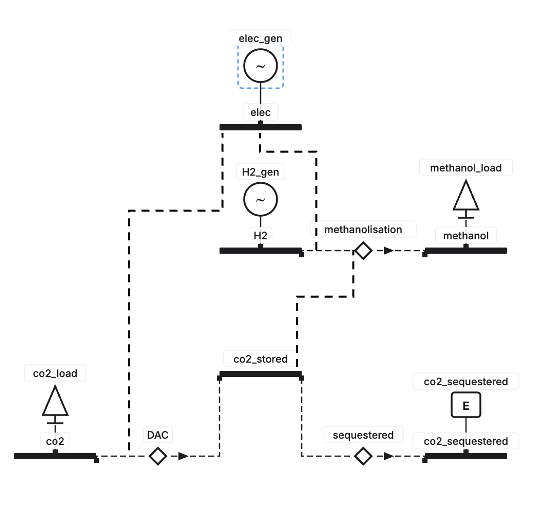

In [10]:
Image("Pic3.png")


In [21]:
## Add elec bus to DAC to have a marginal cost

import pypsa
import numpy as np

# Create network
n = pypsa.Network()
n.set_snapshots(range(7))  # Adjust as needed

# --- Buses ---
n.add(
    "Bus",
    "elec",
    carrier="AC",
)

n.add(
    "Generator",
    "elec_gen",
    bus="elec",
    carrier="AC",
    p_nom=100,
    marginal_cost=[1,1,1,10,1,1,1],
)

n.add(
    "Bus",
    "H2",
    carrier="H2",
)

n.add(
    "Generator",
    "H2_gen",
    bus="H2",
    p_nom=10,
    marginal_cost=1,
)


n.add(
    "Bus",
    "methanol",
    carrier="methanol",
)

n.add(
    "Load",
    "methanol_load",
    bus="methanol",
    p_set=1,
)

n.add(
    "Bus",
    "co2",
    carrier="CO2",
)


n.add(
    "Load",
    "co2_load",
    bus="co2",
    carrier="CO2",
    p_set=-10,
    #marginal_cost=[-10,-10,-30,-30,-30,-10,-10], #[-1,-1,-3,-3,-3,-1,-1],
)

n.add(
    "Bus",
    "co2_stored",
    carrier="CO2",
)


n.add(
    "Bus",
    "co2_sequestered",
    carrier="CO2",
)


# --- Links ---
n.add(
        "Link",
        "DAC",
        bus0='co2',
        bus1='co2_stored',
        bus2='elec',
        carrier="co2",
        p_nom_extendable=True,
        capital_cost=100,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
        efficiency2=-1,
    )

n.add(
        "Link",
        "sequestered",
        bus0='co2_stored',
        bus1='co2_sequestered',
        carrier="co2",
        p_nom_extendable=True,
        capital_cost=0,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
    )

n.add(
        "Link",
        "methanolisation",
        bus0='H2',
        bus1='methanol',
        bus2='elec',
        bus3='co2_stored',
        carrier="methanolisation",
        p_nom_extendable=True,
        p_min_pu=0,
        capital_cost=100,  # EUR/MW_H2/a
        marginal_cost=100,
        lifetime=20,
        efficiency=0.8787,
        efficiency2=-0.238085,
        efficiency3=-0.217926,
    )

#----stores----#

n.add(
        "Store",
        "co2_sequestered",
        bus='co2_sequestered',
        carrier="co2",
        e_nom_extendable=True,
        capital_cost=0,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
    )

# --- Solve ---
n.optimize(solver_name="gurobi")  # Uncomment to solve
n.statistics()  # View results


Index(['elec_gen'], dtype='object', name='Generator')
Index(['DAC', 'sequestered', 'methanolisation'], dtype='object', name='Link')
Index(['co2_load'], dtype='object', name='Load')
Index(['elec', 'H2', 'methanol', 'co2', 'co2_stored', 'co2_sequestered'], dtype='object', name='Bus')
Index(['co2_sequestered'], dtype='object', name='Store')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io: Writing time: 0.06s


Set parameter TokenServer to value "sophia1.hpc.ait.dtu.dk"


INFO:gurobipy:Set parameter TokenServer to value "sophia1.hpc.ait.dtu.dk"


Read LP format model from file /tmp/linopy-problem-g0okhebj.lp


INFO:gurobipy:Read LP format model from file /tmp/linopy-problem-g0okhebj.lp


...

Solved in 0 iterations and 0.01 seconds (0.00 work units)


INFO:gurobipy:Solved in 0 iterations and 0.01 seconds (0.00 work units)


Optimal objective  2.082737408e+03


INFO:gurobipy:Optimal objective  2.082737408e+03
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 53 primals, 137 duals
Objective: 2.08e+03
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


Optimal Capacity  Installed Capacity     Supply  \
Generator -                        10.00000                10.0    7.96631   
          AC                      100.00000               100.0   71.89666   
Link      co2                      19.75199                 0.0  138.26393   
          methanolisation           1.13804                 0.0    7.00000   
Load      -                         0.00000                 0.0    0.00000   
          CO2                       0.00000                 0.0   70.00000   
Store     co2                      68.26393                 0.0    0.00000   

                           Withdrawal  Energy Balance  Transmission  \
Generator -                   0.00000         7.96631       0.00000   
          AC                  0.00000        71.89666       0.00000   
Link      co2               208.26393       -70.00000     138.26393   
          methanolisation    11.59904        -4.59904       0.00000   
Load      -                   7.00000        -7.00000       0.00000   
          CO2                 0.00000        70.00000       0.00000   
Store     co2                68.26393       -68.26393       0.00000   

                           Capacity Factor  Curtailment  Capital Expenditure  \
Generator -                       0.113804     62.03369              0.00000   
          AC                      0.102709    628.10334              0.00000   
Link      co2                     1.000000      0.00000           1000.00000   
          methanolisation         1.000000      0.00000            113.80448   
Load      -                            NaN      0.00000              0.00000   
          CO2                          NaN      0.00000              0.00000   
Store     co2                     0.571429      0.00000              0.00000   

                           Operational Expenditure     Revenue  Market Value  
Generator -                                7.96631     7.96631      1.000000  
          AC                             164.33522   164.33522      2.285715  
Link      co2                              0.00000  1000.00000      7.232544  
          methanolisation                796.63139   910.43587    130.062270  
Load      -                                0.00000  -922.73741           NaN  
          CO2                              0.00000 -1160.00000    -16.571429  
Store     co2                              0.00000     0.00000      0.000000

In [22]:
n.buses_t.marginal_price

Bus,elec,H2,methanol,co2,co2_stored,co2_sequestered
snapshot,,,,,,
0,1.0,1.0,229.017964,-101.0,0.0,0.0
1,1.0,1.0,115.213480,-1.0,0.0,0.0
2,1.0,1.0,115.213480,-1.0,0.0,0.0
3,10.0,1.0,117.652043,-10.0,0.0,0.0
4,1.0,1.0,115.213480,-1.0,0.0,0.0
5,1.0,1.0,115.213480,-1.0,0.0,0.0
6,1.0,1.0,115.213480,-1.0,0.0,0.0


### To see isolated effect of CO2 cost on methanol, electricity is removed from methanolisation link

### result: CO2 stored price is still zero, so it has no effect on cost of methanol.

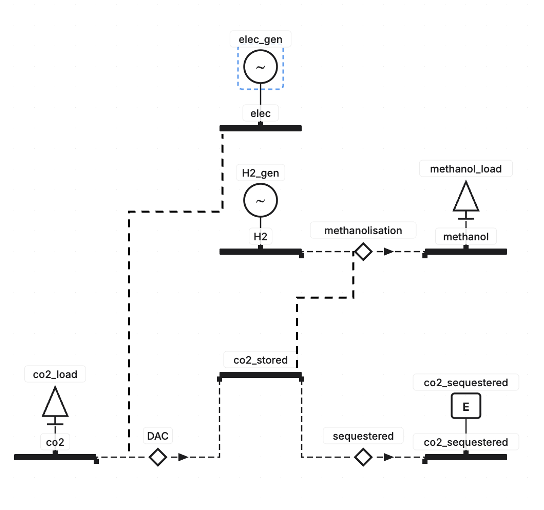

In [12]:
Image("Pic4.png")


In [15]:
## Add elec bus to DAC to have a marginal cost

import pypsa
import numpy as np

# Create network
n = pypsa.Network()
n.set_snapshots(range(7))  # Adjust as needed

# --- Buses ---
n.add(
    "Bus",
    "elec",
    carrier="AC",
)

n.add(
    "Generator",
    "elec_gen",
    bus="elec",
    carrier="AC",
    p_nom=100,
    marginal_cost=[1,1,1,10,1,1,1],
)

n.add(
    "Bus",
    "H2",
    carrier="H2",
)

n.add(
    "Generator",
    "H2_gen",
    bus="H2",
    p_nom=10,
    marginal_cost=1,
)


n.add(
    "Bus",
    "methanol",
    carrier="methanol",
)

n.add(
    "Load",
    "methanol_load",
    bus="methanol",
    p_set=1,
)

n.add(
    "Bus",
    "co2",
    carrier="CO2",
)


n.add(
    "Load",
    "co2_load",
    bus="co2",
    carrier="CO2",
    p_set=-10,
    #marginal_cost=[-10,-10,-30,-30,-30,-10,-10], #[-1,-1,-3,-3,-3,-1,-1],
)

n.add(
    "Bus",
    "co2_stored",
    carrier="CO2",
)


n.add(
    "Bus",
    "co2_sequestered",
    carrier="CO2",
)


# --- Links ---
n.add(
        "Link",
        "DAC",
        bus0='co2',
        bus1='co2_stored',
        bus2='elec',
        carrier="co2",
        p_nom_extendable=True,
        capital_cost=100,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
        efficiency2=-1,
    )

n.add(
        "Link",
        "sequestered",
        bus0='co2_stored',
        bus1='co2_sequestered',
        carrier="co2",
        p_nom_extendable=True,
        capital_cost=0,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
    )

n.add(
        "Link",
        "methanolisation",
        bus0='H2',
        bus1='methanol',
        #bus2='elec',
        bus2='co2_stored',
        carrier="methanolisation",
        p_nom_extendable=True,
        p_min_pu=0,
        capital_cost=100,  # EUR/MW_H2/a
        marginal_cost=100,
        lifetime=20,
        efficiency=0.8787,
      #  efficiency2=-0.238085,
        efficiency2=-0.217926,
    )

#----stores----#

n.add(
        "Store",
        "co2_sequestered",
        bus='co2_sequestered',
        carrier="co2",
        e_nom_extendable=True,
        capital_cost=0,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
    )

# --- Solve ---
n.optimize(solver_name="gurobi")  # Uncomment to solve
n.statistics()  # View results


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


Index(['co2_sequestered'], dtype='object', name='Store')
Index(['DAC', 'sequestered', 'methanolisation'], dtype='object', name='Link')
Index(['elec_gen'], dtype='object', name='Generator')
Index(['elec', 'H2', 'methanol', 'co2', 'co2_stored', 'co2_sequestered'], dtype='object', name='Bus')
Index(['co2_load'], dtype='object', name='Load')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io: Writing time: 0.06s


Set parameter TokenServer to value "sophia1.hpc.ait.dtu.dk"


INFO:gurobipy:Set parameter TokenServer to value "sophia1.hpc.ait.dtu.dk"


Read LP format model from file /tmp/linopy-problem-p0p1wfu3.lp


...

Solved in 0 iterations and 0.01 seconds (0.00 work units)


INFO:gurobipy:Solved in 0 iterations and 0.01 seconds (0.00 work units)


Optimal objective  2.078402185e+03


INFO:gurobipy:Optimal objective  2.078402185e+03
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 53 primals, 137 duals
Objective: 2.08e+03
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


Optimal Capacity  Installed Capacity     Supply  \
Generator -                        10.00000                10.0    7.96631   
          AC                      100.00000               100.0   70.00000   
Link      co2                      19.75199                 0.0  138.26393   
          methanolisation           1.13804                 0.0    7.00000   
Load      -                         0.00000                 0.0    0.00000   
          CO2                       0.00000                 0.0   70.00000   
Store     co2                      68.26393                 0.0    0.00000   

                           Withdrawal  Energy Balance  Transmission  \
Generator -                   0.00000         7.96631       0.00000   
          AC                  0.00000        70.00000       0.00000   
Link      co2               208.26393       -70.00000     138.26393   
          methanolisation     9.70238        -2.70238       0.00000   
Load      -                   7.00000        -7.00000       0.00000   
          CO2                 0.00000        70.00000       0.00000   
Store     co2                68.26393       -68.26393       0.00000   

                           Capacity Factor  Curtailment  Capital Expenditure  \
Generator -                       0.113804     62.03369              0.00000   
          AC                      0.100000    630.00000              0.00000   
Link      co2                     1.000000      0.00000           1000.00000   
          methanolisation         1.000000      0.00000            113.80448   
Load      -                            NaN      0.00000              0.00000   
          CO2                          NaN      0.00000              0.00000   
Store     co2                     0.571429      0.00000              0.00000   

                           Operational Expenditure     Revenue  Market Value  
Generator -                                7.96631     7.96631      1.000000  
          AC                             160.00000   160.00000      2.285714  
Link      co2                              0.00000  1000.00000      7.232544  
          methanolisation                796.63139   910.43587    130.062270  
Load      -                                0.00000  -918.40219           NaN  
          CO2                              0.00000 -1160.00000    -16.571429  
Store     co2                              0.00000     0.00000      0.000000

In [16]:
n.buses_t.marginal_price

Bus,elec,H2,methanol,co2,co2_stored,co2_sequestered
snapshot,,,,,,
0,1.0,1.0,228.747013,-101.0,0.0,0.0
1,1.0,1.0,114.942529,-1.0,0.0,0.0
2,1.0,1.0,114.942529,-1.0,0.0,0.0
3,10.0,1.0,114.942529,-10.0,0.0,0.0
4,1.0,1.0,114.942529,-1.0,0.0,0.0
5,1.0,1.0,114.942529,-1.0,0.0,0.0
6,1.0,1.0,114.942529,-1.0,0.0,0.0


## Case 4 : Network with DAC and sequestration

### Electricity is used for the DAC
### The CO2 sequestered bus has a link and a store. Now we add a capital cost to the store.
### H2 and elec. still have fixed exogenous prices
### only H2 is used for methanolisation to isolate effect of CO2 price on methanol price

### ------------------
### Result:
### CO2 price (still negative) = CO2 sequestered pric (also negative, and equal to CO2 stored price since sequestration link has no cost) + DAC cost (= cost of electricity consumption) 
### CO2 sequestered price equals capital cost of store and is also negative (1 unit CO2 is added to the store in each timestep, so the margianl cost is equal to the capital cost, which is for building one extra unit of energy capacity in each timestep). 

### Since CO2 stored price does not change, price of methanol does not change as well

### When we run pypsa-eur, the price of CO2 bus is constant (lagrange multiplier of global CO2 constraint) and the CO2 stored price changes

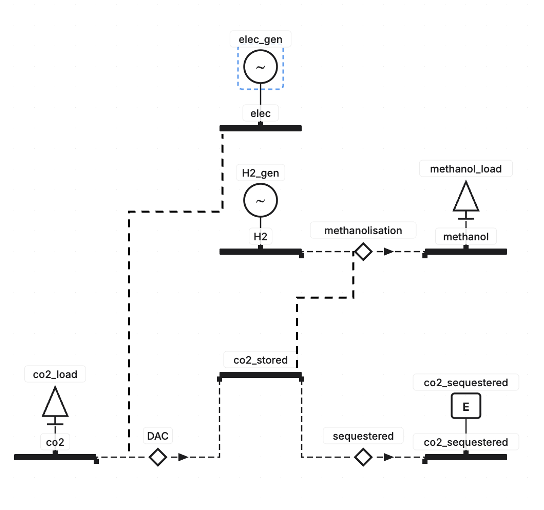

In [17]:
Image("Pic4.png")


In [26]:
## Add capital cost for sequestration store

import pypsa
import numpy as np

# Create network
n = pypsa.Network()
n.set_snapshots(range(7))  # Adjust as needed

# --- Buses ---
n.add(
    "Bus",
    "elec",
    carrier="AC",
)

n.add(
    "Generator",
    "elec_gen",
    bus="elec",
    carrier="AC",
    p_nom=100,
    marginal_cost=[1,1,1,9,1,1,1],
)

n.add(
    "Bus",
    "H2",
    carrier="H2",
)

n.add(
    "Generator",
    "H2_gen",
    bus="H2",
    p_nom=10,
    marginal_cost=1,
)


n.add(
    "Bus",
    "methanol",
    carrier="methanol",
)

n.add(
    "Load",
    "methanol_load",
    bus="methanol",
    p_set=1,
)

n.add(
    "Bus",
    "co2",
    carrier="CO2",
)


n.add(
    "Load",
    "co2_load",
    bus="co2",
    carrier="CO2",
    p_set=-10,
    #marginal_cost=[-10,-10,-30,-30,-30,-10,-10], #[-1,-1,-3,-3,-3,-1,-1],
)

n.add(
    "Bus",
    "co2_stored",
    carrier="CO2",
)


n.add(
    "Bus",
    "co2_sequestered",
    carrier="CO2",
)


# --- Links ---
n.add(
        "Link",
        "DAC",
        bus0='co2',
        bus1='co2_stored',
        bus2='elec',
        carrier="co2",
        p_nom_extendable=True,
        capital_cost=100,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
        efficiency2=-1,
    )

n.add(
        "Link",
        "sequestered",
        bus0='co2_stored',
        bus1='co2_sequestered',
        carrier="co2",
        p_nom_extendable=True,
        capital_cost=0,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
    )

n.add(
        "Link",
        "methanolisation",
        bus0='H2',
        bus1='methanol',
        #bus2='elec',
        bus2='co2_stored',
        carrier="methanolisation",
        p_nom_extendable=True,
        p_min_pu=0,
        capital_cost=100,  # EUR/MW_H2/a
        marginal_cost=100,
        lifetime=20,
        efficiency=0.8787,
      #  efficiency2=-0.238085,
        efficiency2=-0.217926,
    )

#----stores----#

n.add(
        "Store",
        "co2_sequestered",
        bus='co2_sequestered',
        carrier="co2",
        e_nom_extendable=True,
        capital_cost=10,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
    )

# --- Solve ---
n.optimize(solver_name="gurobi")  # Uncomment to solve
n.statistics()  # View results


Index(['co2_sequestered'], dtype='object', name='Store')
Index(['DAC', 'sequestered', 'methanolisation'], dtype='object', name='Link')
Index(['elec_gen'], dtype='object', name='Generator')
Index(['elec', 'H2', 'methanol', 'co2', 'co2_stored', 'co2_sequestered'], dtype='object', name='Bus')
Index(['co2_load'], dtype='object', name='Load')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io: Writing time: 0.06s


Set parameter TokenServer to value "sophia1.hpc.ait.dtu.dk"


INFO:gurobipy:Set parameter TokenServer to value "sophia1.hpc.ait.dtu.dk"


Read LP format model from file /tmp/linopy-problem-9_rirlzh.lp


INFO:gurobipy:Read LP format model from file /tmp/linopy-problem-9_rirlzh.lp


...

Solved in 0 iterations and 0.01 seconds (0.00 work units)


INFO:gurobipy:Solved in 0 iterations and 0.01 seconds (0.00 work units)


Optimal objective  2.751041516e+03


INFO:gurobipy:Optimal objective  2.751041516e+03
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 53 primals, 137 duals
Objective: 2.75e+03
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


Optimal Capacity  Installed Capacity     Supply  \
Generator -                        10.00000                10.0    7.96631   
          AC                      100.00000               100.0   70.00000   
Link      co2                      19.75199                 0.0  138.26393   
          methanolisation           1.13804                 0.0    7.00000   
Load      -                         0.00000                 0.0    0.00000   
          CO2                       0.00000                 0.0   70.00000   
Store     co2                      68.26393                 0.0    0.00000   

                           Withdrawal  Energy Balance  Transmission  \
Generator -                   0.00000         7.96631       0.00000   
          AC                  0.00000        70.00000       0.00000   
Link      co2               208.26393       -70.00000     138.26393   
          methanolisation     9.70238        -2.70238       0.00000   
Load      -                   7.00000        -7.00000       0.00000   
          CO2                 0.00000        70.00000       0.00000   
Store     co2                68.26393       -68.26393       0.00000   

                           Capacity Factor  Curtailment  Capital Expenditure  \
Generator -                       0.113804     62.03369              0.00000   
          AC                      0.100000    630.00000              0.00000   
Link      co2                     1.000000      0.00000           1000.00000   
          methanolisation         1.000000      0.00000            113.80448   
Load      -                            NaN      0.00000              0.00000   
          CO2                          NaN      0.00000              0.00000   
Store     co2                     0.571429      0.00000            682.63933   

                           Operational Expenditure     Revenue  Market Value  
Generator -                                7.96631     7.96631      1.000000  
          AC                             150.00000   150.00000      2.142857  
Link      co2                              0.00000  1000.00000      7.232544  
          methanolisation                796.63139   910.43587    130.062270  
Load      -                                0.00000  -901.04152           NaN  
          CO2                              0.00000 -1850.00000    -26.428571  
Store     co2                              0.00000   682.63933           NaN

In [27]:
n.buses_t.marginal_price

Bus,elec,H2,methanol,co2,co2_stored,co2_sequestered
snapshot,,,,,,
0,1.0,1.0,226.266917,-111.0,-10.0,-10.0
1,1.0,1.0,112.462433,-11.0,-10.0,-10.0
2,1.0,1.0,112.462433,-11.0,-10.0,-10.0
3,9.0,1.0,112.462433,-19.0,-10.0,-10.0
4,1.0,1.0,112.462433,-11.0,-10.0,-10.0
5,1.0,1.0,112.462433,-11.0,-10.0,-10.0
6,1.0,1.0,112.462433,-11.0,-10.0,-10.0


### We add a changing marginal cost to the CO2 sequestration link to see how the price of CO2 affects methanol price

### Result: the lower price for CO2 stored (-20 < -10) makes methanol cheaper.
### Could this be a result of using artificial prices instead of a global CO2 constraint?

In [22]:
import pypsa
import numpy as np

# Create network
n = pypsa.Network()
n.set_snapshots(range(7))  # Adjust as needed

# --- Buses ---
n.add(
    "Bus",
    "elec",
    carrier="AC",
)

n.add(
    "Generator",
    "elec_gen",
    bus="elec",
    carrier="AC",
    p_nom=100,
    marginal_cost=[1,1,1,9,1,1,1],
)

n.add(
    "Bus",
    "H2",
    carrier="H2",
)

n.add(
    "Generator",
    "H2_gen",
    bus="H2",
    p_nom=10,
    marginal_cost=1,
)


n.add(
    "Bus",
    "methanol",
    carrier="methanol",
)

n.add(
    "Load",
    "methanol_load",
    bus="methanol",
    p_set=1,
)

n.add(
    "Bus",
    "co2",
    carrier="CO2",
)


n.add(
    "Load",
    "co2_load",
    bus="co2",
    carrier="CO2",
    p_set=-10,
)

n.add(
    "Bus",
    "co2_stored",
    carrier="CO2",
)


n.add(
    "Bus",
    "co2_sequestered",
    carrier="CO2",
)


# --- Links ---
n.add(
        "Link",
        "DAC",
        bus0='co2',
        bus1='co2_stored',
        bus2='elec',
        carrier="co2",
        p_nom_extendable=True,
        capital_cost=100,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
        efficiency2=-1,
    )

n.add(
        "Link",
        "sequestered",
        bus0='co2_stored',
        bus1='co2_sequestered',
        carrier="co2",
        p_nom_extendable=True,
        capital_cost=0,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
        marginal_cost=[0,0,0,0,0,0,10], 
    )

n.add(
        "Link",
        "methanolisation",
        bus0='H2',
        bus1='methanol',
        #bus2='elec',
        bus2='co2_stored',
        carrier="methanolisation",
        p_nom_extendable=True,
        p_min_pu=0,
        capital_cost=100,  # EUR/MW_H2/a
        marginal_cost=100,
        lifetime=20,
        efficiency=0.8787,
      #  efficiency2=-0.238085,
        efficiency2=-0.217926,
    )

#----stores----#

n.add(
        "Store",
        "co2_sequestered",
        bus='co2_sequestered',
        carrier="co2",
        e_nom_extendable=True,
        capital_cost=10,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
    )

# --- Solve ---
n.optimize(solver_name="gurobi")  # Uncomment to solve
n.statistics()  # View results


Index(['co2_sequestered'], dtype='object', name='Store')
Index(['DAC', 'sequestered', 'methanolisation'], dtype='object', name='Link')
Index(['elec_gen'], dtype='object', name='Generator')
Index(['elec', 'H2', 'methanol', 'co2', 'co2_stored', 'co2_sequestered'], dtype='object', name='Bus')
Index(['co2_load'], dtype='object', name='Load')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io: Writing time: 0.06s


Set parameter TokenServer to value "sophia1.hpc.ait.dtu.dk"


INFO:gurobipy:Set parameter TokenServer to value "sophia1.hpc.ait.dtu.dk"


Read LP format model from file /tmp/linopy-problem-op5phrrp.lp


INFO:gurobipy:Read LP format model from file /tmp/linopy-problem-op5phrrp.lp


...

Solved in 0 iterations and 0.01 seconds (0.00 work units)


INFO:gurobipy:Solved in 0 iterations and 0.01 seconds (0.00 work units)


Optimal objective  2.848561420e+03


INFO:gurobipy:Optimal objective  2.848561420e+03
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 53 primals, 137 duals
Objective: 2.85e+03
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


Optimal Capacity  Installed Capacity     Supply  \
Generator -                        10.00000                10.0    7.96631   
          AC                      100.00000               100.0   70.00000   
Link      co2                      19.75199                 0.0  138.26393   
          methanolisation           1.13804                 0.0    7.00000   
Load      -                         0.00000                 0.0    0.00000   
          CO2                       0.00000                 0.0   70.00000   
Store     co2                      68.26393                 0.0    0.00000   

                           Withdrawal  Energy Balance  Transmission  \
Generator -                   0.00000         7.96631       0.00000   
          AC                  0.00000        70.00000       0.00000   
Link      co2               208.26393       -70.00000     138.26393   
          methanolisation     9.70238        -2.70238       0.00000   
Load      -                   7.00000        -7.00000       0.00000   
          CO2                 0.00000        70.00000       0.00000   
Store     co2                68.26393       -68.26393       0.00000   

                           Capacity Factor  Curtailment  Capital Expenditure  \
Generator -                       0.113804     62.03369              0.00000   
          AC                      0.100000    630.00000              0.00000   
Link      co2                     1.000000      0.00000           1000.00000   
          methanolisation         1.000000      0.00000            113.80448   
Load      -                            NaN      0.00000              0.00000   
          CO2                          NaN      0.00000              0.00000   
Store     co2                     0.571429      0.00000            682.63933   

                           Operational Expenditure     Revenue  Market Value  
Generator -                                7.96631     7.96631      1.000000  
          AC                             150.00000   150.00000      2.142857  
Link      co2                             97.51990  1097.51990      7.937861  
          methanolisation                796.63139   910.43587    130.062270  
Load      -                                0.00000  -898.56142           NaN  
          CO2                              0.00000 -1950.00000    -27.857143  
Store     co2                              0.00000   682.63933           NaN

In [25]:
n.buses_t.marginal_price

Bus,elec,H2,methanol,co2,co2_stored,co2_sequestered
snapshot,,,,,,
0,1.0,1.0,226.266917,-111.0,-10.0,-10.0
1,1.0,1.0,112.462433,-11.0,-10.0,-10.0
2,1.0,1.0,112.462433,-11.0,-10.0,-10.0
3,9.0,1.0,112.462433,-19.0,-10.0,-10.0
4,1.0,1.0,112.462433,-11.0,-10.0,-10.0
5,1.0,1.0,112.462433,-11.0,-10.0,-10.0
6,1.0,1.0,109.982338,-21.0,-20.0,-10.0


## Case 5 : Network with DAC and sequestration and co2 emissions

### Negative CO2 load is removed, all CO2 (at each timestep) has to be either sequestered or used for methanolisation.
### A gas link and gas demand are also added.

### ------------------
### Results: With zero costs for gas generator and link, the marginal cost of gas bus is equal to the :
### CO2 emitted* CO2_price
### CO2 price is still sum of DAC cost and sequestration cost

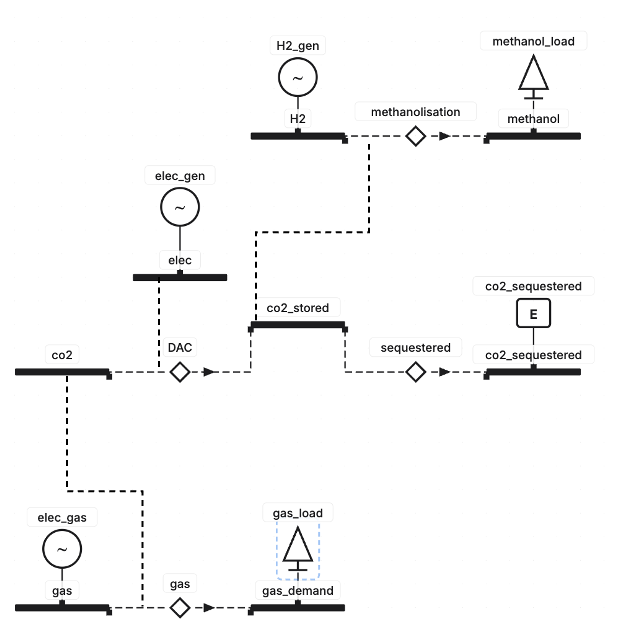

In [38]:
Image("Pic5.png")


In [42]:
import pypsa
import numpy as np

# Create network
n = pypsa.Network()
n.set_snapshots(range(7))  # Adjust as needed


# --- Buses ---
n.add(
    "Bus",
    "elec",
    carrier="AC",
)

n.add(
    "Generator",
    "elec_gen",
    bus="elec",
    carrier="AC",
    p_nom=100,
    marginal_cost=[1,1,1,9,1,1,1],
)

n.add(
    "Bus",
    "H2",
    carrier="H2",
)

n.add(
    "Generator",
    "H2_gen",
    bus="H2",
    p_nom=10,
    marginal_cost=1,
)


n.add(
    "Bus",
    "methanol",
    carrier="methanol",
)

n.add(
    "Load",
    "methanol_load",
    bus="methanol",
    p_set=1,
)

n.add(
    "Bus",
    "co2",
    carrier="CO2",
)


n.add(
    "Bus",
    "co2_stored",
    carrier="CO2",
)


n.add(
    "Bus",
    "co2_sequestered",
    carrier="CO2",
)


n.add(
    "Bus",
    "gas",
    carrier="gas",
)

n.add(
    "Generator",
    "gas_gen",
    bus="gas",
    carrier="gas",
    p_nom=100,
    capital_cost=0,
    #marginal_cost=[1,1,1,1,1,1,1],
)

n.add(
    "Bus",
    "gas_demand",
    carrier="gas",
)

n.add(
    "Load",
    "gas_load",
    bus="gas_demand",
    p_set=1,
)

# --- Links ---
n.add(
        "Link",
        "DAC",
        bus0='co2',
        bus1='co2_stored',
        bus2='elec',
        carrier="co2",
        p_nom_extendable=True,
        capital_cost=100,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
        efficiency2=-1,
    )

n.add(
        "Link",
        "sequestered",
        bus0='co2_stored',
        bus1='co2_sequestered',
        carrier="co2",
        p_nom_extendable=True,
        capital_cost=0,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
    )

n.add(
        "Link",
        "methanolisation",
        bus0='H2',
        bus1='methanol',
        bus2='elec',
        bus3='co2_stored',
        carrier="methanolisation",
        p_nom_extendable=True,
        p_min_pu=0,
        capital_cost=100,  # EUR/MW_H2/a
        marginal_cost=100,
        lifetime=20,
        efficiency=0.8787,
        efficiency2=-0.238085,
        efficiency3=-0.217926,
    )

n.add(
        "Link",
        "gas",
        bus0='gas',
        bus1='gas_demand',
        bus2='co2',
        carrier="gas",
        p_nom_extendable=True,
        capital_cost=0,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
        efficiency2=0.5,
)

#----stores----#

n.add(
        "Store",
        "co2_sequestered",
        bus='co2_sequestered',
        carrier="co2",
        e_nom_extendable=True,
        capital_cost=10,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
    )



# --- Solve ---
n.optimize(solver_name="gurobi")  # Uncomment to solve
n.statistics()  # View results


Index(['co2_sequestered'], dtype='object', name='Store')
Index(['DAC', 'sequestered', 'methanolisation', 'gas'], dtype='object', name='Link')
Index(['elec_gen', 'gas_gen'], dtype='object', name='Generator')
Index(['elec', 'H2', 'methanol', 'co2', 'co2_stored', 'co2_sequestered', 'gas',
       'gas_demand'],
      dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io: Writing time: 0.06s


Set parameter TokenServer to value "sophia1.hpc.ait.dtu.dk"


INFO:gurobipy:Set parameter TokenServer to value "sophia1.hpc.ait.dtu.dk"


Read LP format model from file /tmp/linopy-problem-cleienn3.lp


INFO:gurobipy:Read LP format model from file /tmp/linopy-problem-cleienn3.lp


...

Solved in 0 iterations and 0.01 seconds (0.00 work units)


INFO:gurobipy:Solved in 0 iterations and 0.01 seconds (0.00 work units)


Optimal objective  9.976057870e+02


INFO:gurobipy:Optimal objective  9.976057870e+02
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 68 primals, 180 duals
Objective: 9.98e+02
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


Optimal Capacity  Installed Capacity    Supply  \
Generator -                        10.00000                10.0   7.96631   
          AC                      100.00000               100.0   5.39666   
          gas                     100.00000               100.0   7.00000   
Link      co2                       0.75199                 0.0   5.26393   
          gas                       1.00000                 0.0  10.50000   
          methanolisation           1.13804                 0.0   7.00000   
Load      -                         0.00000                 0.0   0.00000   
Store     co2                       1.76393                 0.0   0.00000   

                           Withdrawal  Energy Balance  Transmission  \
Generator -                   0.00000         7.96631       0.00000   
          AC                  0.00000         5.39666       0.00000   
          gas                 0.00000         7.00000       0.00000   
Link      co2                 8.76393        -3.50000       5.26393   
          gas                 7.00000         3.50000       7.00000   
          methanolisation    11.59904        -4.59904       0.00000   
Load      -                  14.00000       -14.00000       0.00000   
Store     co2                 1.76393        -1.76393       0.00000   

                           Capacity Factor  Curtailment  Capital Expenditure  \
Generator -                       0.113804     62.03369              0.00000   
          AC                      0.007710    694.60334              0.00000   
          gas                     0.010000    693.00000              0.00000   
Link      co2                     1.000000      0.00000             50.00000   
          gas                     1.000000      0.00000              0.00000   
          methanolisation         1.000000      0.00000            113.80448   
Load      -                            NaN      0.00000              0.00000   
Store     co2                     0.571429      0.00000             17.63933   

                           Operational Expenditure    Revenue  Market Value  
Generator -                                7.96631    7.96631      1.000000  
          AC                              11.56427   11.56427      2.142863  
          gas                              0.00000    0.00000           NaN  
Link      co2                              0.00000   50.00000      9.498610  
          gas                              0.00000    0.00000           NaN  
          methanolisation                796.63139  910.43587    130.062270  
Load      -                                0.00000 -997.60579           NaN  
Store     co2                              0.00000   17.63933           NaN

In [43]:
n.buses_t.marginal_price

Bus,elec,H2,methanol,co2,co2_stored,co2_sequestered,gas,gas_demand
snapshot,,,,,,,,
0,1.0,1.0,226.537868,-111.0,-10.0,-10.0,0.0,55.5
1,1.0,1.0,112.733385,-11.0,-10.0,-10.0,0.0,5.5
2,1.0,1.0,112.733385,-11.0,-10.0,-10.0,0.0,5.5
3,9.0,1.0,114.900996,-19.0,-10.0,-10.0,0.0,9.5
4,1.0,1.0,112.733385,-11.0,-10.0,-10.0,0.0,5.5
5,1.0,1.0,112.733385,-11.0,-10.0,-10.0,0.0,5.5
6,1.0,1.0,112.733385,-11.0,-10.0,-10.0,0.0,5.5


In [44]:
n.links_t.p0

Link,DAC,sequestered,methanolisation,gas
snapshot,,,,
0,0.5,0.25199,1.138045,1.0
1,0.5,0.25199,1.138045,1.0
2,0.5,0.25199,1.138045,1.0
3,0.5,0.25199,1.138045,1.0
4,0.5,0.25199,1.138045,1.0
5,0.5,0.25199,1.138045,1.0
6,0.5,0.25199,1.138045,1.0


In [45]:
n.links_t.p1

Link,DAC,sequestered,methanolisation,gas
snapshot,,,,
0,-0.5,-0.25199,-1.0,-1.0
1,-0.5,-0.25199,-1.0,-1.0
2,-0.5,-0.25199,-1.0,-1.0
3,-0.5,-0.25199,-1.0,-1.0
4,-0.5,-0.25199,-1.0,-1.0
5,-0.5,-0.25199,-1.0,-1.0
6,-0.5,-0.25199,-1.0,-1.0


In [46]:
n.links_t.p2

Link,DAC,sequestered,methanolisation,gas
snapshot,,,,
0,0.5,0.0,0.270951,-0.5
1,0.5,0.0,0.270951,-0.5
2,0.5,0.0,0.270951,-0.5
3,0.5,0.0,0.270951,-0.5
4,0.5,0.0,0.270951,-0.5
5,0.5,0.0,0.270951,-0.5
6,0.5,0.0,0.270951,-0.5


In [47]:
n.links_t.p3

Link,DAC,sequestered,methanolisation,gas
snapshot,,,,
0,0.0,0.0,0.24801,0.0
1,0.0,0.0,0.24801,0.0
2,0.0,0.0,0.24801,0.0
3,0.0,0.0,0.24801,0.0
4,0.0,0.0,0.24801,0.0
5,0.0,0.0,0.24801,0.0
6,0.0,0.0,0.24801,0.0


In [48]:
n.stores_t.p

Store,co2_sequestered
snapshot,
0,-0.25199
1,-0.25199
2,-0.25199
3,-0.25199
4,-0.25199
5,-0.25199
6,-0.25199


### We add a changing marginal cost to the CO2 sequestration link to see how the price of CO2 affects methanol price

### ------------------
### Results: same as before, methanol is cheaper with cheaper co2-stored price
### Let's add emissions to methanol as well since gas marginal price goes up when co2 price increases

In [50]:
import pypsa
import numpy as np

# Create network
n = pypsa.Network()
n.set_snapshots(range(7))  # Adjust as needed


# --- Buses ---
n.add(
    "Bus",
    "elec",
    carrier="AC",
)

n.add(
    "Generator",
    "elec_gen",
    bus="elec",
    carrier="AC",
    p_nom=100,
    marginal_cost=[1,1,1,9,1,1,1],
)

n.add(
    "Bus",
    "H2",
    carrier="H2",
)

n.add(
    "Generator",
    "H2_gen",
    bus="H2",
    p_nom=10,
    marginal_cost=1,
)


n.add(
    "Bus",
    "methanol",
    carrier="methanol",
)

n.add(
    "Load",
    "methanol_load",
    bus="methanol",
    p_set=1,
)

n.add(
    "Bus",
    "co2",
    carrier="CO2",
)


n.add(
    "Bus",
    "co2_stored",
    carrier="CO2",
)


n.add(
    "Bus",
    "co2_sequestered",
    carrier="CO2",
)


n.add(
    "Bus",
    "gas",
    carrier="gas",
)

n.add(
    "Generator",
    "gas_gen",
    bus="gas",
    carrier="gas",
    p_nom=100,
    capital_cost=0,
    #marginal_cost=[1,1,1,1,1,1,1],
)

n.add(
    "Bus",
    "gas_demand",
    carrier="gas",
)

n.add(
    "Load",
    "gas_load",
    bus="gas_demand",
    p_set=1,
)

# --- Links ---
n.add(
        "Link",
        "DAC",
        bus0='co2',
        bus1='co2_stored',
        bus2='elec',
        carrier="co2",
        p_nom_extendable=True,
        capital_cost=100,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
        efficiency2=-1,
    )

n.add(
        "Link",
        "sequestered",
        bus0='co2_stored',
        bus1='co2_sequestered',
        carrier="co2",
        p_nom_extendable=True,
        capital_cost=0,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
        marginal_cost=[0,0,0,0,0,0,10], 
    )

n.add(
        "Link",
        "methanolisation",
        bus0='H2',
        bus1='methanol',
        bus2='elec',
        bus3='co2_stored',
        carrier="methanolisation",
        p_nom_extendable=True,
        p_min_pu=0,
        capital_cost=100,  # EUR/MW_H2/a
        marginal_cost=100,
        lifetime=20,
        efficiency=0.8787,
        efficiency2=-0.238085,
        efficiency3=-0.217926,
    )

n.add(
        "Link",
        "gas",
        bus0='gas',
        bus1='gas_demand',
        bus2='co2',
        carrier="gas",
        p_nom_extendable=True,
        capital_cost=0,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
        efficiency2=0.5,
)

#----stores----#

n.add(
        "Store",
        "co2_sequestered",
        bus='co2_sequestered',
        carrier="co2",
        e_nom_extendable=True,
        capital_cost=10,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
    )



# --- Solve ---
n.optimize(solver_name="gurobi")  # Uncomment to solve
n.statistics()  # View results


Index(['co2_sequestered'], dtype='object', name='Store')
Index(['DAC', 'sequestered', 'methanolisation', 'gas'], dtype='object', name='Link')
Index(['elec_gen', 'gas_gen'], dtype='object', name='Generator')
Index(['elec', 'H2', 'methanol', 'co2', 'co2_stored', 'co2_sequestered', 'gas',
       'gas_demand'],
      dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io: Writing time: 0.06s


Set parameter TokenServer to value "sophia1.hpc.ait.dtu.dk"


INFO:gurobipy:Set parameter TokenServer to value "sophia1.hpc.ait.dtu.dk"


Read LP format model from file /tmp/linopy-problem-obwoeis2.lp


INFO:gurobipy:Read LP format model from file /tmp/linopy-problem-obwoeis2.lp


...

Solved in 0 iterations and 0.01 seconds (0.00 work units)


INFO:gurobipy:Solved in 0 iterations and 0.01 seconds (0.00 work units)


Optimal objective  1.000125691e+03


INFO:gurobipy:Optimal objective  1.000125691e+03
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 68 primals, 180 duals
Objective: 1.00e+03
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


Optimal Capacity  Installed Capacity    Supply  \
Generator -                        10.00000                10.0   7.96631   
          AC                      100.00000               100.0   5.39666   
          gas                     100.00000               100.0   7.00000   
Link      co2                       0.75199                 0.0   5.26393   
          gas                       1.00000                 0.0  10.50000   
          methanolisation           1.13804                 0.0   7.00000   
Load      -                         0.00000                 0.0   0.00000   
Store     co2                       1.76393                 0.0   0.00000   

                           Withdrawal  Energy Balance  Transmission  \
Generator -                   0.00000         7.96631       0.00000   
          AC                  0.00000         5.39666       0.00000   
          gas                 0.00000         7.00000       0.00000   
Link      co2                 8.76393        -3.50000       5.26393   
          gas                 7.00000         3.50000       7.00000   
          methanolisation    11.59904        -4.59904       0.00000   
Load      -                  14.00000       -14.00000       0.00000   
Store     co2                 1.76393        -1.76393       0.00000   

                           Capacity Factor  Curtailment  Capital Expenditure  \
Generator -                       0.113804     62.03369              0.00000   
          AC                      0.007710    694.60334              0.00000   
          gas                     0.010000    693.00000              0.00000   
Link      co2                     1.000000      0.00000             50.00000   
          gas                     1.000000      0.00000              0.00000   
          methanolisation         1.000000      0.00000            113.80448   
Load      -                            NaN      0.00000              0.00000   
Store     co2                     0.571429      0.00000             17.63933   

                           Operational Expenditure     Revenue  Market Value  
Generator -                                7.96631     7.96631      1.000000  
          AC                              11.56427    11.56427      2.142863  
          gas                              0.00000     0.00000           NaN  
Link      co2                              2.51990    52.51990      9.977314  
          gas                              0.00000     0.00000           NaN  
          methanolisation                796.63139   910.43587    130.062270  
Load      -                                0.00000 -1000.12569           NaN  
Store     co2                              0.00000    17.63933           NaN

In [51]:
n.buses_t.marginal_price

Bus,elec,H2,methanol,co2,co2_stored,co2_sequestered,gas,gas_demand
snapshot,,,,,,,,
0,1.0,1.0,226.537868,-111.0,-10.0,-10.0,0.0,55.5
1,1.0,1.0,112.733385,-11.0,-10.0,-10.0,0.0,5.5
2,1.0,1.0,112.733385,-11.0,-10.0,-10.0,0.0,5.5
3,9.0,1.0,114.900996,-19.0,-10.0,-10.0,0.0,9.5
4,1.0,1.0,112.733385,-11.0,-10.0,-10.0,0.0,5.5
5,1.0,1.0,112.733385,-11.0,-10.0,-10.0,0.0,5.5
6,1.0,1.0,110.253289,-21.0,-20.0,-10.0,0.0,10.5


## Case 6: Network with DAC, sequestration, CO2 emissions (for both gas and methanol)

### A buffer bus is added between methanol demand and methanol production to model co2 emissions from methanol.
### PyPSA-EUR: the co2 emissions are exactly equal to the CO2 used for production of methanol

### --------
### Result
### Price of methanol now includes carbon 'tax'.
### Because of this, mehtnal is now more expensive during hour with lower (more negative) CO2 price
### HOWEVER, the methanol_buffer bus still has cheaper methanol during hour with lower CO2 price
### So the conclusion is methanol_buffer bus is not a good way to estimate production cost of methanol,
### since the carbon cycle for methanol is still not completed at this bus.

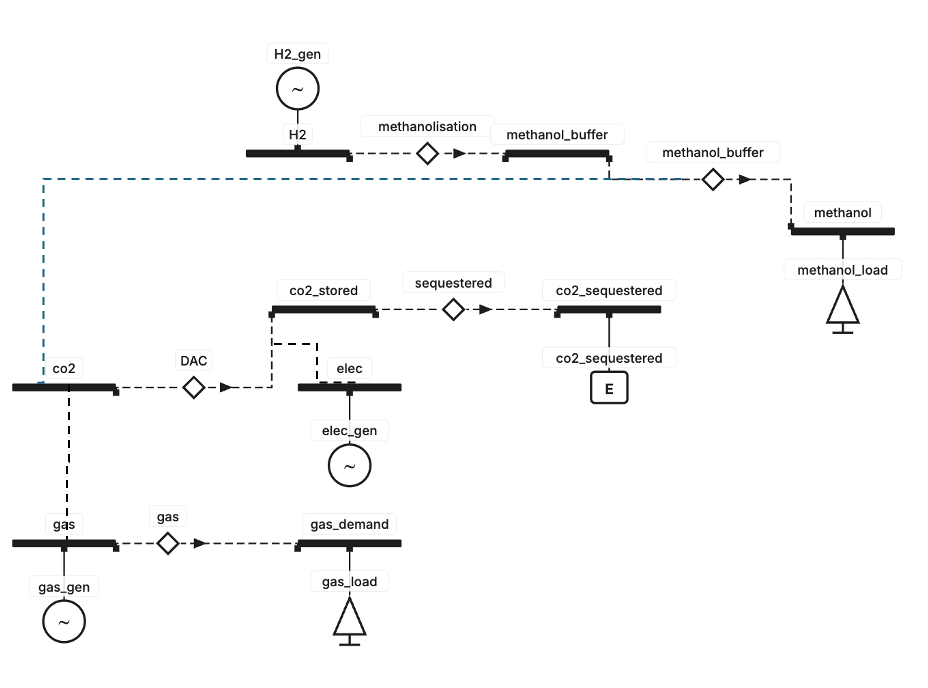

In [47]:
Image("Pic6.png")


In [56]:
## add marginal cost to CO2 sequestered store  ->> HAS to be negative otherwise it
## is subtracted from capital cost

import pypsa
import numpy as np

# Create network
n = pypsa.Network()
n.set_snapshots(range(7))  # Adjust as needed

# --- Buses ---
n.add(
    "Bus",
    "elec",
    carrier="AC",
)

n.add(
    "Generator",
    "elec_gen",
    bus="elec",
    carrier="AC",
    p_nom=100,
    marginal_cost=[1,1,1,10,1,1,1],
)

n.add(
    "Bus",
    "H2",
    carrier="H2",
)

n.add(
    "Generator",
    "H2_gen",
    bus="H2",
    p_nom=10,
    marginal_cost=1,
)

n.add(
    "Bus",
    "methanol_buffer",
    carrier="methanol",
)


n.add(
    "Bus",
    "methanol",
    carrier="methanol",
)

n.add(
    "Load",
    "methanol_load",
    bus="methanol",
    p_set=1,
)

n.add(
    "Bus",
    "co2",
    carrier="CO2",
)


n.add(
    "Bus",
    "co2_stored",
    carrier="CO2",
)


n.add(
    "Bus",
    "co2_sequestered",
    carrier="CO2",
)

n.add(
    "Bus",
    "gas",
    carrier="gas",
)

n.add(
    "Generator",
    "gas_gen",
    bus="gas",
    carrier="gas",
    p_nom=100,
    capital_cost=0,
    #marginal_cost=[1,1,1,1,1,1,1],
)

n.add(
    "Bus",
    "gas_demand",
    carrier="gas",
)

n.add(
    "Load",
    "gas_load",
    bus="gas_demand",
    p_set=1,
)

# --- Links ---
n.add(
        "Link",
        "DAC",
        bus0='co2',
        bus1='co2_stored',
        bus2='elec',
        carrier="co2",
        p_nom_extendable=True,
        capital_cost=100,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
        efficiency2=-1,
    )

n.add(
        "Link",
        "sequestered",
        bus0='co2_stored',
        bus1='co2_sequestered',
        carrier="co2",
        p_nom_extendable=True,
        capital_cost=0,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
    )

n.add(
        "Link",
        "methanolisation",
        bus0='H2',
        bus1='methanol_buffer',
        bus2='elec',
        bus3='co2_stored',
        carrier="methanolisation",
        p_nom_extendable=True,
        p_min_pu=0,
        capital_cost=100,  # EUR/MW_H2/a
        marginal_cost=100,
        lifetime=20,
        efficiency=0.8787,
        efficiency2=-0.238085,
        efficiency3=-0.217926,
    )

n.add(
        "Link",
        "methanol_buffer",
        bus0='methanol_buffer',
        bus1='methanol',
        bus3='co2',
        carrier="methanol",
        p_nom_extendable=True,
        capital_cost=0,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
        efficiency2=0.24801,
    )

n.add(
        "Link",
        "gas",
        bus0='gas',
        bus1='gas_demand',
        bus2='co2',
        carrier="gas",
        p_nom_extendable=True,
        capital_cost=0,  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
        efficiency2=0.5,
)
#----stores----#

n.add(
        "Store",
        "co2_sequestered",
        bus='co2_sequestered',
        carrier="co2",
        e_nom_extendable=True,
        capital_cost=10,  # EUR/MW_H2/a
       # marginal_cost=[0,0,0,0,0,0,-10],  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
    )

# --- Solve ---
n.optimize(solver_name="gurobi")  # Uncomment to solve
n.statistics()  # View results


Index(['co2_sequestered'], dtype='object', name='Store')
Index(['DAC', 'sequestered', 'methanolisation', 'methanol_buffer', 'gas'], dtype='object', name='Link')
Index(['elec_gen', 'gas_gen'], dtype='object', name='Generator')
Index(['elec', 'H2', 'methanol_buffer', 'methanol', 'co2', 'co2_stored',
       'co2_sequestered', 'gas', 'gas_demand'],
      dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io: Writing time: 0.06s


Set parameter TokenServer to value "sophia1.hpc.ait.dtu.dk"


INFO:gurobipy:Set parameter TokenServer to value "sophia1.hpc.ait.dtu.dk"


Read LP format model from file /tmp/linopy-problem-uvgownxu.lp


INFO:gurobipy:Read LP format model from file /tmp/linopy-problem-uvgownxu.lp


...

Solved in 0 iterations and 0.01 seconds (0.00 work units)


INFO:gurobipy:Solved in 0 iterations and 0.01 seconds (0.00 work units)


Optimal objective  1.196896643e+03


INFO:gurobipy:Optimal objective  1.196896643e+03
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 76 primals, 202 duals
Objective: 1.20e+03
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


Optimal Capacity  Installed Capacity    Supply  \
Generator -                        10.00000                10.0   7.96631   
          AC                      100.00000               100.0  12.39666   
          gas                     100.00000               100.0   7.00000   
Link      co2                       2.75199                 0.0  19.26393   
          gas                       1.00000                 0.0  10.50000   
          methanol                  1.00000                 0.0  14.00000   
          methanolisation           1.13804                 0.0   7.00000   
Load      -                         0.00000                 0.0   0.00000   
Store     co2                       8.76393                 0.0   0.00000   

                           Withdrawal  Energy Balance  Transmission  \
Generator -                   0.00000         7.96631       0.00000   
          AC                  0.00000        12.39666       0.00000   
          gas                 0.00000         7.00000       0.00000   
Link      co2                29.76393       -10.50000      19.26393   
          gas                 7.00000         3.50000       7.00000   
          methanol            7.00000         7.00000       7.00000   
          methanolisation    11.59904        -4.59904       0.00000   
Load      -                  14.00000       -14.00000       0.00000   
Store     co2                 8.76393        -8.76393       0.00000   

                           Capacity Factor  Curtailment  Capital Expenditure  \
Generator -                       0.113804     62.03369              0.00000   
          AC                      0.017709    687.60334              0.00000   
          gas                     0.010000    693.00000              0.00000   
Link      co2                     1.000000      0.00000            150.00000   
          gas                     1.000000      0.00000              0.00000   
          methanol                1.000000      0.00000              0.00000   
          methanolisation         1.000000      0.00000            113.80448   
Load      -                            NaN      0.00000              0.00000   
Store     co2                     0.571429      0.00000             87.63933   

                           Operational Expenditure     Revenue  Market Value  
Generator -                                7.96631     7.96631      1.000000  
          AC                              28.33522    28.33522      2.285717  
          gas                              0.00000     0.00000           NaN  
Link      co2                              0.00000   150.00000      7.786573  
          gas                              0.00000     0.00000           NaN  
          methanol                         0.00000     0.00000           NaN  
          methanolisation                796.63139   910.43587    130.062270  
Load      -                                0.00000 -1196.89664           NaN  
Store     co2                             12.51990   100.15924           NaN

In [53]:
n.buses_t.marginal_price

Bus,elec,H2,methanol_buffer,methanol,co2,co2_stored,co2_sequestered,gas,gas_demand
snapshot,,,,,,,,,
0,1.0,1.0,226.537868,337.537868,-111.0,-10.0,-10.0,0.0,55.5
1,1.0,1.0,112.733385,123.733385,-11.0,-10.0,-10.0,0.0,5.5
2,1.0,1.0,112.733385,123.733385,-11.0,-10.0,-10.0,0.0,5.5
3,10.0,1.0,115.171947,135.171947,-20.0,-10.0,-10.0,0.0,10.0
4,1.0,1.0,112.733385,123.733385,-11.0,-10.0,-10.0,0.0,5.5
5,1.0,1.0,112.733385,123.733385,-11.0,-10.0,-10.0,0.0,5.5
6,1.0,1.0,112.733385,123.733385,-11.0,-10.0,-10.0,0.0,5.5


## if  co2_sequestered has variable marginal cost:

In [ ]:
n.add(
        "Store",
        "co2_sequestered",
        bus='co2_sequestered',
        carrier="co2",
        e_nom_extendable=True,
        capital_cost=10,  # EUR/MW_H2/a
        marginal_cost=[0,0,0,0,0,0,10],  # EUR/MW_H2/a
        lifetime=20,
        efficiency=1,
    )

In [58]:
n.buses_t.marginal_price

Bus,elec,H2,methanol_buffer,methanol,co2,co2_stored,co2_sequestered,gas,gas_demand
snapshot,,,,,,,,,
0,1.0,1.0,226.537868,337.537868,-111.0,-10.0,-10.0,0.0,55.5
1,1.0,1.0,112.733385,123.733385,-11.0,-10.0,-10.0,0.0,5.5
2,1.0,1.0,112.733385,123.733385,-11.0,-10.0,-10.0,0.0,5.5
3,10.0,1.0,115.171947,135.171947,-20.0,-10.0,-10.0,0.0,10.0
4,1.0,1.0,112.733385,123.733385,-11.0,-10.0,-10.0,0.0,5.5
5,1.0,1.0,112.733385,123.733385,-11.0,-10.0,-10.0,0.0,5.5
6,1.0,1.0,110.253289,131.253289,-21.0,-20.0,-20.0,0.0,10.5
